<a href="https://colab.research.google.com/github/MinThuKhant763/machine-learning/blob/main/K_Mean_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('/content/income.csv')
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    22 non-null     object
 1   Age     22 non-null     int64 
 2   Income  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [35]:
X = data[['Age','Income']]
print(X)

    Age  Income
0    27   70000
1    29   90000
2    29   61000
3    28   60000
4    42  150000
5    39  155000
6    41  160000
7    38  162000
8    36  156000
9    35  130000
10   37  137000
11   26   45000
12   27   48000
13   28   51000
14   29   49500
15   32   53000
16   40   65000
17   41   63000
18   43   64000
19   39   80000
20   41   82000
21   39   58000


In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x = sc.fit_transform(X)
x = pd.DataFrame(x)
x.columns=['Age','Income']

In [37]:
from sklearn.cluster import KMeans
k_m = KMeans(n_clusters=3)
k_m.fit(x)
y_pred = k_m.predict(x)
print(f"Cluster memberships:\n {k_m.labels_}")

Cluster memberships:
 [1 1 1 1 2 2 2 2 2 2 2 1 1 1 1 1 0 0 0 0 0 0]


In [38]:
x['Cluster'] = y_pred
x

,Age,Income,Cluster
0,-1.356055,-0.480684,1
1,-1.009157,-0.010159,1
2,-1.009157,-0.692421,1
3,-1.182606,-0.715947,1
4,1.245679,1.401417,2
5,0.725332,1.519048,2
6,1.072230,1.636679,2
7,0.551883,1.683732,2
8,0.204985,1.542574,2
9,0.031536,0.930891,2


In [39]:
centroids = k_m.cluster_centers_
centroids

array([[ 0.98550535, -0.51205261],
       [-1.1247901 , -0.74862223],
       [ 0.60143983,  1.40141653]])

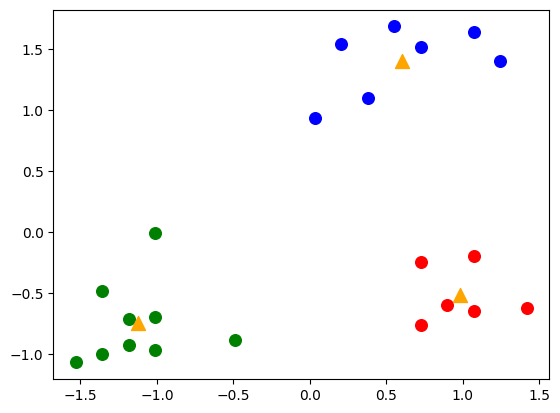

In [40]:
x1 = x[x["Cluster"]==0]
x2 = x[x["Cluster"]==1]
x3 = x[x["Cluster"]==2]

plt.scatter(x1['Age'],x1['Income'],color='red',s=70)
plt.scatter(x2['Age'],x2['Income'],color='green',s=70)
plt.scatter(x3['Age'],x3['Income'],color='blue',s=70)
plt.scatter(centroids[:,0],centroids[:,1],color='orange',marker='^',s=100)

In [41]:
print(k_m.inertia_)

3.8893086571301416


In [44]:
ks = range(2,10)
intertias = []
for i in ks:
  model = KMeans(n_clusters=i,random_state=42)
  model.fit(x)
  intertias.append(model.inertia_)

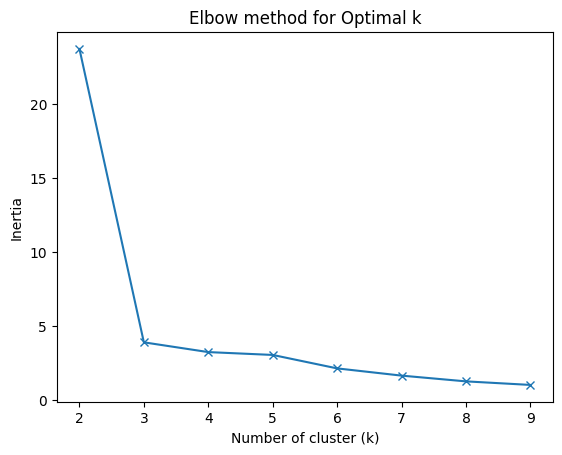

In [46]:
plt.plot(ks,intertias,'-x')
plt.xlabel("Number of cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow method for Optimal k")
plt.xticks(ks)
plt.show()